# SMT World — activity analysis (sanitized)

**Google Gen AI Academy APAC · Cohort 2 · Challenge 2**

This notebook visualises SMT's decision **activity** from BigQuery (`smtworld.public_activity`) —
the ingest → analyze → **visualize** slice of the pipeline. It runs in **BigQuery Studio** (Colab
Enterprise runtime) or **Google Colab**.

> **MOAT — read first.** Only **sanitized aggregates** appear here: decision *counts*, action *mix*,
> and *average* conviction/risk per pair/hour. The alpha — raw signal params, per-pair research,
> calibrated thresholds, and live PnL — is **never** in this view and must never be added. This is a
> real system's public slice, shown responsibly.

In [1]:
# Auth + config. In BigQuery Studio the runtime is already authed; in Colab this prompts once.
PROJECT = "smt-bot-2026-v2"
try:
    from google.colab import auth  # noqa
    auth.authenticate_user()
except Exception:
    pass  # BigQuery Studio / ADC — already authenticated

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project=PROJECT)
print("connected to", PROJECT)

connected to smt-bot-2026-v2


In [2]:
# Pull the sanitized public view into a DataFrame.
df = client.query("""
  SELECT hour, pair, action, decisions, avg_conviction, avg_risk
  FROM `smt-bot-2026-v2.smtworld.public_activity`
  ORDER BY hour
""").to_dataframe()
print(f"{len(df)} rows  ·  {df['pair'].nunique()} pairs  ·  {df['hour'].nunique()} hour-buckets")
df.head()

24 rows  ·  8 pairs  ·  3 hour-buckets


,hour,pair,action,decisions,avg_conviction,avg_risk
0,2026-06-30 00:00:00+00:00,ETH,LONG,10,0.72,28.0
1,2026-06-30 00:00:00+00:00,DOGE,LONG,10,0.72,28.0
2,2026-06-30 00:00:00+00:00,XRP,LONG,10,0.73,27.0
3,2026-06-30 00:00:00+00:00,LTC,SHORT,10,0.59,41.0
4,2026-06-30 00:00:00+00:00,BTC,SHORT,10,0.90,10.0


## 1. How many decisions per pair?

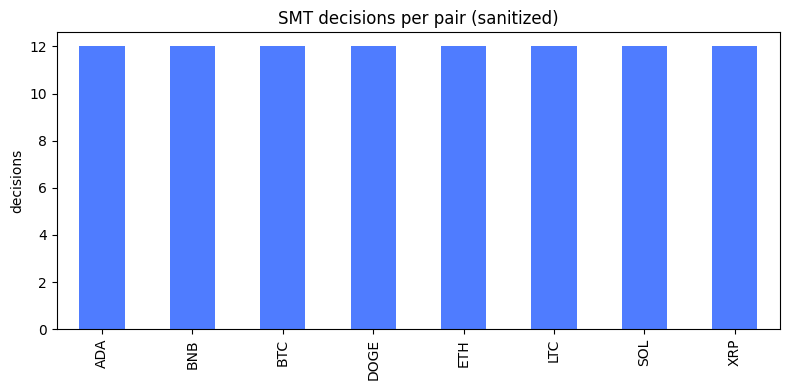

In [3]:
by_pair = df.groupby("pair")["decisions"].sum().sort_values(ascending=False)
ax = by_pair.plot(kind="bar", color="#4f7cff", figsize=(8, 4))
ax.set_title("SMT decisions per pair (sanitized)"); ax.set_ylabel("decisions"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 2. Action mix (LONG / SHORT / WAIT) per pair

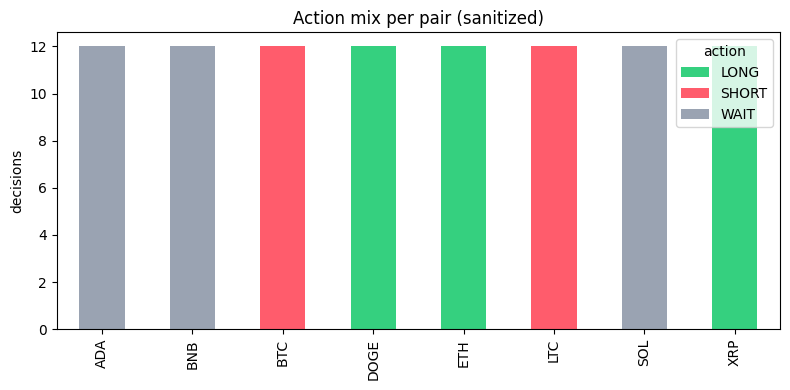

In [4]:
mix = df.pivot_table(index="pair", columns="action", values="decisions", aggfunc="sum", fill_value=0)
colors = {"LONG": "#35d07f", "SHORT": "#ff5c6c", "WAIT": "#9aa3b2"}
ax = mix.plot(kind="bar", stacked=True, figsize=(8, 4),
              color=[colors.get(c, "#888") for c in mix.columns])
ax.set_title("Action mix per pair (sanitized)"); ax.set_ylabel("decisions"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 3. Average conviction per pair

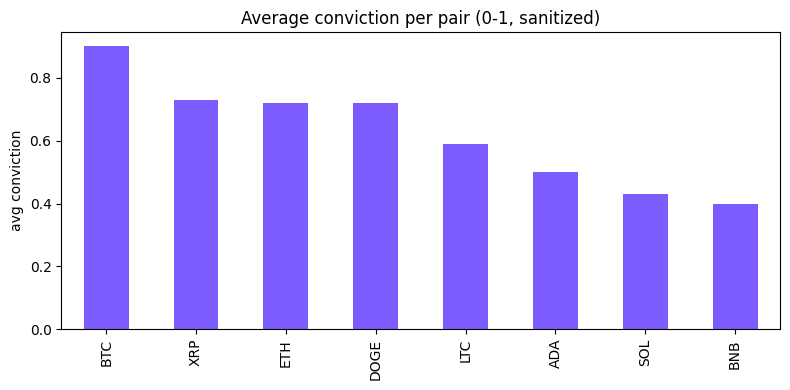

In [5]:
conv = df.groupby("pair")["avg_conviction"].mean().sort_values(ascending=False)
ax = conv.plot(kind="bar", color="#7c5cff", figsize=(8, 4))
ax.set_title("Average conviction per pair (0-1, sanitized)"); ax.set_ylabel("avg conviction"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 4. Conviction over time (all pairs)

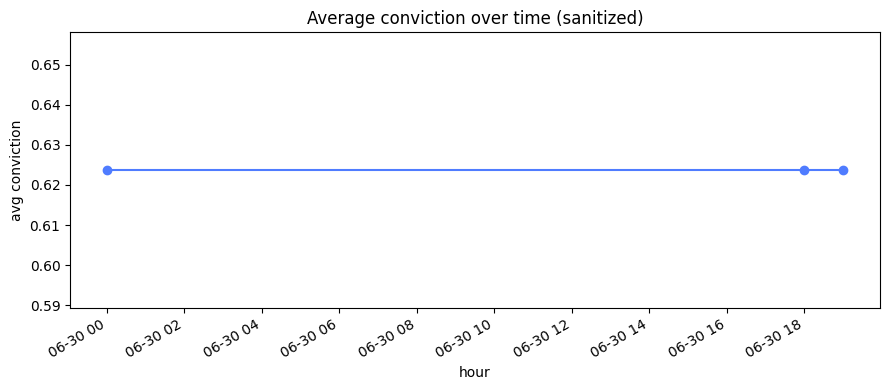

In [6]:
ts = df.groupby("hour")["avg_conviction"].mean()
if len(ts) > 1:
    ax = ts.plot(figsize=(9, 4), marker="o", color="#4f7cff")
    ax.set_title("Average conviction over time (sanitized)"); ax.set_ylabel("avg conviction")
    plt.tight_layout(); plt.show()
else:
    print("Only one hour-bucket so far — let the live app run longer for a trend line.")

## 5. (Optional) Forecast with BigQuery ML — `AI_FORECAST`
Cohort 2 Track 2 move: let BigQuery forecast near-term activity. Counts only — still sanitized.

In [7]:
# Forecast total decisions/hour for the next few buckets. (Needs enough history to be meaningful.)
fc = client.query("""
  SELECT * FROM AI.FORECAST(
    (SELECT hour AS ts, SUM(decisions) AS total
     FROM `smt-bot-2026-v2.smtworld.public_activity` GROUP BY hour),
    data_col => 'total', timestamp_col => 'ts', horizon => 6)
""").to_dataframe()
fc.head(10)

,forecast_timestamp,forecast_value,confidence_level,prediction_interval_lower_bound,prediction_interval_upper_bound,ai_forecast_status
0,2026-07-01 12:00:00+00:00,41.499619,0.95,-28.767525,112.379430,
1,2026-07-02 06:00:00+00:00,39.799606,0.95,-32.657035,113.851813,
2,2026-07-03 00:00:00+00:00,47.309452,0.95,-24.695561,118.303432,
3,2026-07-03 18:00:00+00:00,42.377670,0.95,-28.955923,110.166328,
4,2026-07-04 12:00:00+00:00,49.721008,0.95,-21.660136,116.321742,
5,2026-07-05 06:00:00+00:00,45.444828,0.95,-25.984152,110.726334,


## 6. Real archived daemon activity (sanitized) — *drop-in for 2nd-round shadow data*
When the 2nd-round shadow-run aggregates are exported (sanitized — counts/mix/avg only, **no**
params/PnL) to e.g. `smtworld.shadow_activity`, point the cell below at that table and the same
charts above tell the story on **real** activity since January. Keep the moat rule: aggregates only.

In [8]:
# TODO (operator, by 2026-07-06): once smtworld.shadow_activity exists, uncomment:
# df = client.query('SELECT hour, pair, action, decisions, avg_conviction, avg_risk \
#                    FROM `smt-bot-2026-v2.smtworld.shadow_activity` ORDER BY hour').to_dataframe()
# ...then re-run cells 1-5 to chart the real (sanitized) activity.
print("placeholder — wire shadow_activity here when the sanitized export lands")

placeholder — wire shadow_activity here when the sanitized export lands
